# Discrepancy: Comparing Samples with Kernels

Author: Fred J. Hickernell

This migrates the 2025 sample-comparison material. Compare Metropolis samples with
IID acceptance–rejection samples from the same bounded banana, distinguish empirical
MMD from its IID-unbiased estimator, and visualize where two samples disagree.

Use the local `qmcpy` Jupyter kernel, or a private Google Colab copy:

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fjhickernell/MATH565Fall2026/blob/main/notebooks/performance/Discrepancy.ipynb)

Run all cells in order. The setup installs the course's recorded dependency commits
and TeX support in Colab. Keep the complete course checkout, including
`notebooks/mcmc_examples.py`. Save a copy in Drive to retain your experiments.

In [1]:
from pathlib import Path
import shutil
import subprocess
import sys
import time

NOTEBOOK_START_TIME = time.perf_counter()

colab = "google.colab" in sys.modules
if colab:
    print("Setting up this course's recorded classlib, QMCPy, and TeX; this may take several minutes …")
    course_checkout = Path("/content/MATH565Fall2026")
    if not course_checkout.exists():
        subprocess.run(
            [
                "git", "clone", "--quiet", "--depth", "1",
                "https://github.com/fjhickernell/MATH565Fall2026.git",
                str(course_checkout),
            ],
            check=True,
        )
    subprocess.run(
        [
            "git", "-C", str(course_checkout),
            "-c", "submodule.classlib.url=https://github.com/fjhickernell/HickernellAcademicLib.git",
            "-c", "submodule.qmcpy.url=https://github.com/QMCSoftware/qmcpy.git",
            "submodule", "update", "--init", "classlib", "qmcpy",
        ],
        check=True,
    )
    if shutil.which("latex") is None:
        subprocess.run(
            [
                "apt-get", "-qq", "install", "-y",
                "cm-super", "dvipng", "texlive-latex-extra",
                "texlive-latex-recommended",
            ],
            check=True,
        )
    subprocess.run(
        [
            sys.executable, "-m", "pip", "install", "-q",
            str(course_checkout / "classlib"),
            str(course_checkout / "qmcpy"),
        ],
        check=True,
    )
    print("Colab setup complete.")
    print("For faster repeated work, use the local `qmcpy` environment.")


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from IPython.display import display, Markdown
import classlib as cl

%matplotlib inline
cl.nbviz.init(use_tex=True)
colors = cl.nbviz.TOL_BRIGHT
rng = np.random.default_rng()

# Locate the same course helper from local Jupyter or the Colab checkout.
search_roots = ([course_checkout] if colab else []) + [Path.cwd(), *Path.cwd().parents]
notebook_dir = next((p / 'notebooks' for p in search_roots
                     if (p / 'notebooks' / 'mcmc_examples.py').is_file()), None)
if notebook_dir is None:
    raise FileNotFoundError('Open this notebook inside the complete MATH565Fall2026 checkout')
sys.path.insert(0, str(notebook_dir))
from mcmc_examples import (log_banana, banana_reference, banana_mean,
                           random_walk_nd, parallel_tempering, mmd_squared, gaussian_kernel, kernel_sum)


## Compare samples from the same target

### The bounded banana reference

Use the same $\exp[-2(1-x_1)^2-60(x_2-x_1^2)^2]$ target on $[0,1]^2$ as the
[acceptance–rejection](../sampling/TransportMapsAndAcceptanceRejection.ipynb) and
[Metropolis](../sampling/MetropolisHastings.ipynb) notebooks. Generate the reference
with the same QMCPy IID rejection sampler. It is a finite random reference sample,
not the target distribution itself.

All candidate samples have the same retained size. Metropolis candidates use
additional burn-in, and rejection sampling uses additional proposals. Here we compare
sample quality at equal retained size, not equal computational effort.

### Fresh runs, not copied outputs

Each notebook can run independently: this one regenerates its samples using the
shared course helper. No execution of another notebook or saved sample file is required.

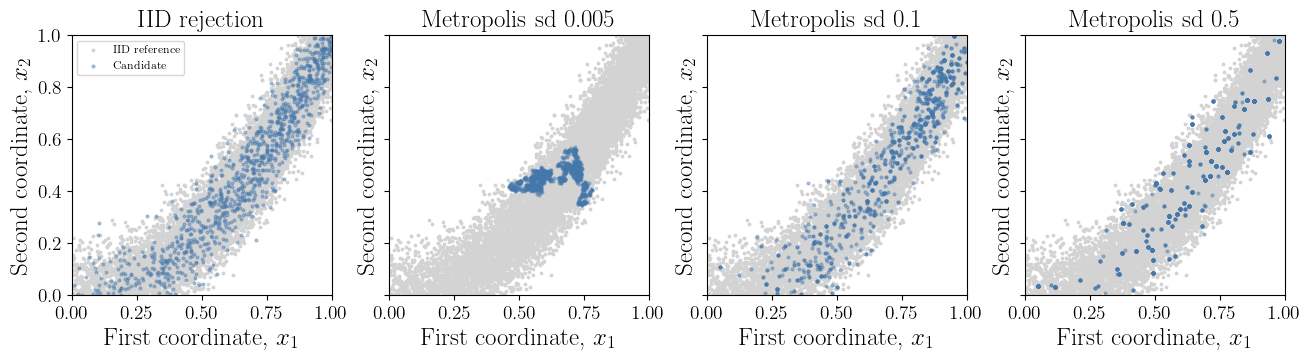

In [3]:
# Retained candidate size, independent AR reference size, discarded chain states.
n_compare, n_reference, burn = 1000, 10000, 1000
reference,mass=banana_reference(n_reference)
ar_sample,_=banana_reference(n_compare)
candidates={'IID rejection':ar_sample}
for sd in [.005,.1,.5]:
    run=random_walk_nd(log_banana,[.5,.5],n_compare+burn,sd,rng)
    candidates[f'Metropolis sd {sd:g}']=run['states'][burn:]
fig,axes=plt.subplots(1,4,figsize=(13,3.5),sharex=True,sharey=True,constrained_layout=True)
for ax,(label,values) in zip(axes,candidates.items()):
    ax.scatter(reference[:,0],reference[:,1],s=3,color='lightgray',label='IID reference')
    ax.scatter(values[:,0],values[:,1],s=4,color=colors['blue'],alpha=.4,label='Candidate')
    ax.set(xlabel='First coordinate, $x_1$',ylabel='Second coordinate, $x_2$',xlim=(0,1),ylim=(0,1),aspect='equal',title=label)
axes[0].legend(fontsize=8,frameon=True)
plt.show()


## Kernel discrepancy

### Empirical distributions and their distance

For points $X=(x_0,\ldots,x_{n-1})$ and $Y=(y_0,\ldots,y_{m-1})$, define
$P_n=n^{-1}\sum_i\delta_{x_i}$ and $Q_m=m^{-1}\sum_j\delta_{y_j}$. With a positive
semidefinite kernel $K$, their squared maximum mean discrepancy is
\begin{align*}
D_K^2(P_n,Q_m)
&=\frac1{n^2}\sum_{i,j=0}^{n-1}K(x_i,x_j)
-\frac2{nm}\sum_{i=0}^{n-1}\sum_{j=0}^{m-1}K(x_i,y_j)
+\frac1{m^2}\sum_{i,j=0}^{m-1}K(y_i,y_j).
\end{align*}
This is the **exact discrepancy between these empirical measures** (up to floating
point error), including when points are dependent. It is nonnegative and is zero
when the empirical measures agree. When used to estimate population MMD from IID
samples, it is generally biased.

Use the Gaussian kernel
\begin{align*}
K_\ell(x,y)&=\exp\left(-\frac{\|x-y\|_2^2}{2\ell^2}\right).
\end{align*}
It compares sample locations at a scale controlled by $\ell$. Smaller $\ell$ focuses
on more local differences; a very broad kernel can obscure them. Rankings and
magnitudes depend on kernel choice. Do not compare raw values across different
kernels as if they had a common calibration.

### The off-diagonal estimator

For two **independent IID samples**, an unbiased estimator of the population squared
MMD is
\begin{align*}
\widehat D_{K,U}^2
&=\frac1{n(n-1)}\sum_{i\ne j}K(x_i,x_j)
-\frac2{nm}\sum_{i,j}K(x_i,y_j)
+\frac1{m(m-1)}\sum_{i\ne j}K(y_i,y_j).
\end{align*}
It estimates a nonnegative population quantity. Across repeated IID samples, smaller
expected values correspond to smaller population MMD. For one realization, however,
a more negative value does not mean a better match; it is a larger downward sampling
fluctuation below zero. Interpret values near zero using repeated runs or calibrated
sampling uncertainty rather than ranking them by raw negativity. For a descriptive
one-run comparison at a fixed kernel and sample sizes, the diagonal-including empirical
MMD squared above remains the nonnegative squared distance between their kernel mean embeddings.
Do not take the off-diagonal estimator's square root or silently truncate it to zero.
For a Metropolis chain, off-diagonal pairs are dependent: **removing the diagonal does
not make this an unbiased population-MMD estimator**. We report that formula as an
“off-diagonal value” for MCMC, preserving the comparison without the IID claim.

| Candidate | Length scale | Empirical MMD squared | Off-diagonal value |
|:---|---:|---:|---:|
| IID rejection | 0.05 | 0.000712 | -0.000329 |
| Metropolis sd 0.005 | 0.05 | 0.247122 | 0.246320 |
| Metropolis sd 0.1 | 0.05 | 0.006840 | 0.005814 |
| Metropolis sd 0.5 | 0.05 | 0.017869 | 0.016840 |
| IID rejection | 0.2 | 0.000069 | -0.000667 |
| Metropolis sd 0.005 | 0.2 | 0.391908 | 0.391670 |
| Metropolis sd 0.1 | 0.2 | 0.012490 | 0.011789 |
| Metropolis sd 0.5 | 0.2 | 0.012707 | 0.011997 |
| IID rejection | 1 | 0.000005 | -0.000117 |
| Metropolis sd 0.005 | 1 | 0.010319 | 0.010300 |
| Metropolis sd 0.1 | 1 | 0.003585 | 0.003474 |
| Metropolis sd 0.5 | 1 | 0.000303 | 0.000196 |

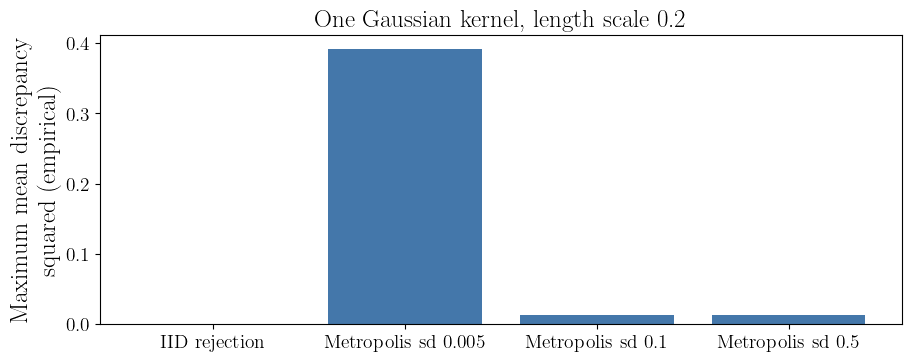

In [4]:
length_scales=[.05,.2,1.]
rows=['| Candidate | Length scale | Empirical MMD squared | Off-diagonal value |',
      '|:---|---:|---:|---:|']
values_by_scale={}
# Reuse the same reference self-comparison for every candidate.
reference_sums = {ell: kernel_sum(reference, reference, ell) for ell in length_scales}
for length_scale in length_scales:
    values_by_scale[length_scale]={}
    for label,values in candidates.items():
        empirical,offdiag=mmd_squared(values, reference, length_scale, reference_sums[length_scale])
        values_by_scale[length_scale][label]=(empirical,offdiag)
        rows.append(f'| {label} | {length_scale:g} | {empirical:.6f} | {offdiag:.6f} |')
display(Markdown('\n'.join(rows)))
fig,ax=plt.subplots(figsize=(9,3.5),constrained_layout=True)
labels=list(candidates)
ax.bar(np.arange(len(labels)),[values_by_scale[.2][label][0] for label in labels],color=colors['blue'])
ax.set(xticks=np.arange(len(labels)),xticklabels=labels,ylabel='Maximum mean discrepancy\nsquared (empirical)',
       title='One Gaussian kernel, length scale 0.2')
plt.show()


## Interpret the discrepancy

### Why the point cloud and discrepancy can disagree

The reference and candidate sizes are set by `n_reference` and `n_compare` above.
The reference is an independent IID AR sample. A larger reference reduces reference-sample noise; it does
not remove the variability or dependence in a short Metropolis run.

A scatter plot can hide repeated states because they occupy the same location.
MMD counts every state, including repetitions, with its full empirical weight.
At kernel length scale 0.2, the distribution of mass along the banana can matter
more than the apparent number of distinct points. Thus a clumpy sd = 0.5 sample
can have smaller discrepancy than a smoother-looking sd = 0.1 sample. Check the
other kernel scales and repeat the experiment before ranking proposal scales.

### A witness function shows where samples differ

The empirical witness function is
\begin{align*}
w(z)&=\frac1n\sum_i K(z,x_i)-\frac1m\sum_j K(z,y_j).
\end{align*}
Positive regions indicate more candidate kernel mass than reference kernel mass;
negative regions indicate less. It is a difference of smoothed empirical measures,
not the target's pointwise density error.

In the kernel's reproducing-kernel Hilbert space,
\begin{align*}
D_K(P_n,Q_m)&=\sup_{\|f\|_{\mathcal H_K}\le1}|P_nf-Q_mf|,\\
\|w\|_{\mathcal H_K}^2&=D_K^2(P_n,Q_m),&P_nw-Q_mw&=D_K^2(P_n,Q_m).
\end{align*}
For nonzero discrepancy, the normalized witness attains this empirical worst-case
integration error. The bound concerns the kernel's function class; it does not
assert that every possible integrand is accurately integrated.

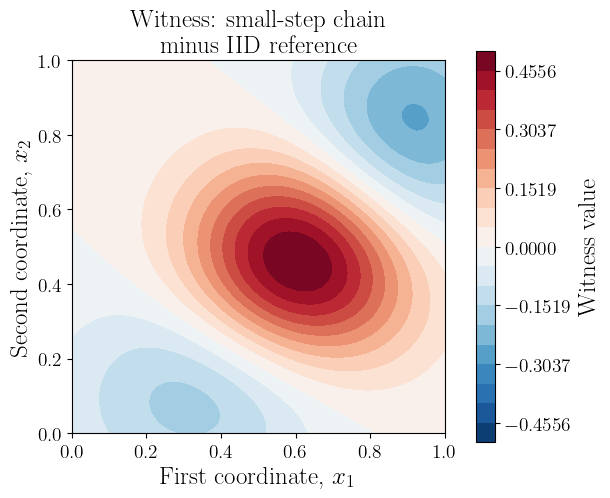

Empirical MMD squared: 0.39190849; witness identity: 0.39190849


In [5]:
candidate=candidates['Metropolis sd 0.005']
length_scale=.2
grid=np.linspace(0,1,80)
grid1,grid2=np.meshgrid(grid,grid)
locations=np.column_stack([grid1.ravel(),grid2.ravel()])
def witness(locations):
    # Small blocks avoid allocating a large grid-by-reference distance array.
    out=[]
    for start in range(0,len(locations),200):
        block=locations[start:start+200]
        out.append(gaussian_kernel(block,candidate,length_scale).mean(axis=1)
                   -gaussian_kernel(block,reference,length_scale).mean(axis=1))
    return np.concatenate(out)
witness_grid=witness(locations).reshape(grid1.shape)
limit=np.max(np.abs(witness_grid))
fig,ax=plt.subplots(figsize=(6,5),constrained_layout=True)
plot=ax.contourf(grid1,grid2,witness_grid,levels=np.linspace(-limit,limit,21),cmap='RdBu_r')
ax.set(xlabel='First coordinate, $x_1$',ylabel='Second coordinate, $x_2$',aspect='equal',title='Witness: small-step chain\nminus IID reference')
fig.colorbar(plot,ax=ax,label='Witness value')
plt.show()
empirical=mmd_squared(candidate, reference, length_scale, reference_sums[length_scale])[0]
witness_identity=witness(candidate).mean()-witness(reference).mean()
assert np.isclose(empirical,witness_identity,rtol=1e-10,atol=1e-12)
print(f'Empirical MMD squared: {empirical:.8f}; witness identity: {witness_identity:.8f}')


### Finite reference uncertainty and familiar integrands

Independent samples from the same target have nonzero empirical discrepancy. Repeat
an IID-versus-IID comparison to see that baseline. The range below is illustrative,
not a calibrated hypothesis test or a confidence interval for a dependent chain.

Also compare an ordinary integration problem, $f(x)=x_1$ and $f(x)=x_2$, with
quadrature. A small error in these two means is useful evidence but does not establish
that the entire distribution has been represented.

In [6]:
iid_baseline=[]
for repetition in range(6):
    fresh,_=banana_reference(n_compare)
    iid_baseline.append(mmd_squared(fresh, reference, .2, reference_sums[.2])[0])
print('IID-versus-reference empirical MMD squared values:',np.round(iid_baseline,6))
exact_mean=banana_mean()
rows=['| Candidate | Mean x1 | Mean x2 | Euclidean error in mean |', '|:---|---:|---:|---:|']
for label,values in candidates.items():
    estimate=values.mean(axis=0)
    rows.append(f'| {label} | {estimate[0]:.4f} | {estimate[1]:.4f} | '
                f'{np.linalg.norm(estimate-exact_mean):.4f} |')
rows.append(f'| Quadrature target | {exact_mean[0]:.4f} | {exact_mean[1]:.4f} | 0 |')
display(Markdown('\n'.join(rows)))


IID-versus-reference empirical MMD squared values: [0.002236 0.000519 0.000244 0.000689 0.000421 0.001297]


| Candidate | Mean x1 | Mean x2 | Euclidean error in mean |
|:---|---:|---:|---:|
| IID rejection | 0.6568 | 0.4831 | 0.0056 |
| Metropolis sd 0.005 | 0.6300 | 0.4529 | 0.0348 |
| Metropolis sd 0.1 | 0.7027 | 0.5294 | 0.0709 |
| Metropolis sd 0.5 | 0.6633 | 0.4888 | 0.0143 |
| Quadrature target | 0.6522 | 0.4797 | 0 |

## Experiments and conclusions

1. Increase candidate and reference sizes separately. Which part of the discrepancy
   is due to finite-reference variation?
2. Vary the Metropolis starting point, proposal scale, and burn-in. Compare means,
   point clouds, and kernel discrepancy; look for conclusions that disagree.
3. Vary the kernel length scale. Explain why a small value with one scale is not a
   universal certificate of sample quality.
4. Verify numerically that empirical MMD is symmetric and vanishes for a sample
   compared with itself. Explain why the off-diagonal estimate need not share these
   nonnegativity/zero properties on realized samples.
5. Why is the IID-unbiased claim unavailable for the dependent Metropolis points?

This keeps the useful 2025 sample comparison while correcting the kernel summation
indices and separating empirical distance from unbiased population estimation.
The exact pairwise calculation takes quadratic work. We sum kernels in blocks
to limit memory and cache the reference self-comparison separately for each kernel
scale. Every reference point is used; there is no reference subsampling.

In [7]:
notebook_elapsed = time.perf_counter() - NOTEBOOK_START_TIME
notebook_minutes, notebook_seconds = divmod(notebook_elapsed, 60)
print(f"Total execution time for this notebook is "
      f"{int(notebook_minutes)} min {notebook_seconds:.1f} sec.")


Total execution time for this notebook is 0 min 17.8 sec.
